In [3]:
import stan
import pandas as pd
import numpy as np
import scipy.stats as stats 
import matplotlib.pyplot as plt
# this is a work around needed to run pystan in some machines
import nest_asyncio
nest_asyncio.apply()

/home/grimm/anaconda3/envs/BML4SR/lib/python3.10/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


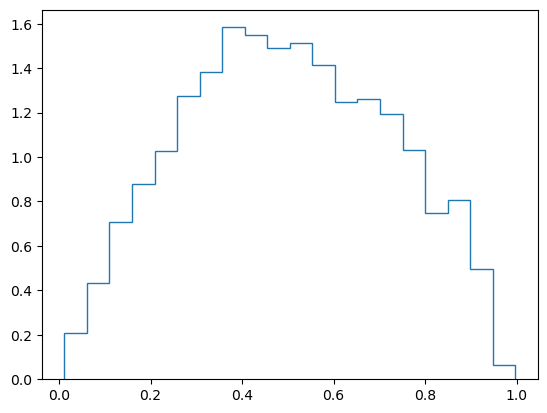

In [4]:
d = np.random.beta(2, 2, 4000)
plt.hist(d, histtype="step", density=True, bins=20)
plt.show()

In [5]:
dataset = pd.read_csv("grades.csv", sep=",", header=0, index_col=0)
selected_data = dataset[dataset["year"]==2018]["grade"]
selected_data

0      0.64
1      0.82
2      0.85
3      0.65
4      0.68
       ... 
595    0.60
596    0.44
597    0.75
598    0.64
599    0.65
Name: grade, Length: 600, dtype: float64

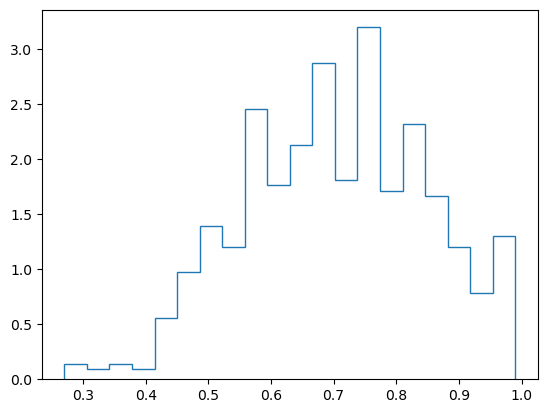

In [6]:
plt.hist(selected_data, histtype="step", density=True, bins=20)
plt.show()

In [ ]:
my_model = """
data {
 int <lower=0> N;  // number of datapoints
 array[N] real <lower=0, upper=1> grades;
}

parameters {
  real <lower=0> p1, q1, p2, q2;  // parameters for the beta functions
  simplex[2] theta;
  ordered[2] nu;
}

model {
    vector[2] lp;
    p1 ~ uniform(0, 20);
    q1 ~ uniform(0, 20);
    p2 ~ uniform(0, 20);
    q2 ~ uniform(0, 20);
    theta ~ dirichlet([1,1]);
    
   for (n in 1:N) {
     lp[1] =   beta_lpdf( grades[n] | p1, q1) ;
     lp[2] =   beta_lpdf( grades[n] | p2, q2) ;
     target += log_mix(theta, lp);                        
     };
}
"""

In [13]:
my_data = {
    'N': selected_data.shape[0],
    'grades': selected_data.values,
    }

In [14]:
model = stan.build(my_model, data=my_data, random_seed=0)

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_ys2qx45l/model_42jb3jpf.stan', line 18, column 4: The
    parameter theta is on the left-hand side of more than one tilde
    statement.
Warning in '/tmp/httpstan_ys2qx45l/model_42jb3jpf.stan', line 17, column 20: Argument
    20 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Warning in '/tmp/httpstan_ys2qx45l/model_42jb3jpf.stan', line 17, column 4: Parameter
    q2 is given a uniform distribution. The uniform distribution is not
    recommended, for two reasons: (a) Except when there are logical or
    physical constraints, it is very unusual for you to be sure that a
    parameter will fall inside a specified range, and (b) The infinite
    gradient induced by a uniform density can cause difficulties for Stan's
    sampling algorithm. As a consequence, we recommend soft constraints
    rather than hard constraints; for example

In [15]:
fit = model.sample(num_chains=4, num_samples=1000, delta=0.8)

Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   0% (2/8000)
Sampling:   0% (3/8000)
Sampling:   0% (4/8000)
Sampling:   1% (103/8000)
Sampling:   3% (202/8000)
Sampling:   4% (301/8000)
Sampling:   5% (400/8000)
Sampling:   6% (500/8000)
Sampling:   8% (600/8000)
Sampling:   9% (700/8000)
Sampling:  10% (800/8000)
Sampling:  11% (900/8000)
Sampling:  12% (1000/8000)
Sampling:  14% (1100/8000)
Sampling:  15% (1200/8000)
Sampling:  16% (1300/8000)
Sampling:  18% (1400/8000)
Sampling:  19% (1500/8000)
Sampling:  20% (1600/8000)
Sampling:  21% (1700/8000)
Sampling:  22% (1800/8000)
Sampling:  24% (1900/8000)
Sampling:  25% (2000/8000)
Sampling:  26% (2100/8000)
Sampling:  28% (2200/8000)
Sampling:  29% (2300/8000)
Sampling:  30% (2400/8000)
Sampling:  31% (2500/8000)
Sampling:  32% (2600/8000)
Sampling:  34% (2700/8000)
Sampling:  35% (2800/8000)
Sampling:  36% (2900/8000)
Sampling:  38% (3000/8000)
Sampling:  39% (3100/8000)
Sampling:  40% (3200/8000)
Sampling:  41% (3300/8000)
Samplin

In [16]:
df = fit.to_frame() 
df

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,p1,q1,p2,q2,theta.1,theta.2
draws,,,,,,,,,,,,,
0,325.599278,0.997106,0.120784,3.0,15.0,0.0,-323.885723,12.541229,1.716984,7.886051,4.072328,0.149584,0.850416
1,325.583015,0.982651,0.131165,4.0,23.0,0.0,-324.965931,15.960773,1.603887,7.724331,3.932183,0.155627,0.844373
2,325.830254,0.884574,0.117161,2.0,3.0,0.0,-325.605483,8.737384,4.597136,12.271176,1.603724,0.779563,0.220437
3,324.486281,0.844905,0.128165,5.0,31.0,0.0,-323.007146,9.196901,4.704006,4.720264,1.442266,0.529681,0.470319
4,327.232814,1.000000,0.120784,2.0,3.0,0.0,-325.637458,13.739126,1.695915,7.971417,3.960870,0.153250,0.846750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,323.957749,0.890196,0.128165,3.0,7.0,0.0,-323.471681,10.058229,5.050048,9.095251,1.398470,0.831645,0.168355
3996,326.474418,0.844207,0.120784,4.0,27.0,0.0,-322.921360,7.434039,1.689463,9.024460,4.738138,0.327962,0.672038
3997,326.468767,0.000000,0.131165,0.0,1.0,1.0,-322.278492,19.767038,1.660758,7.825132,3.741682,0.082017,0.917983


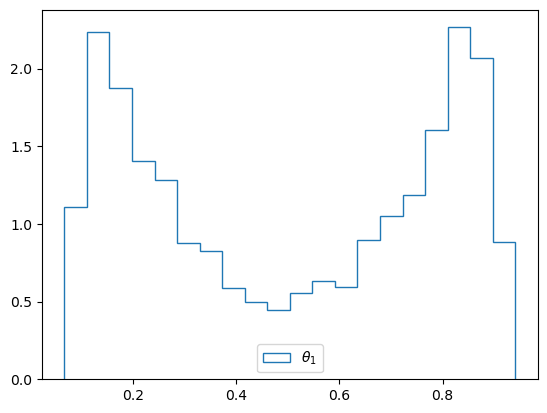

In [20]:
x=np.linspace(0,0.08,100)
plt.hist(df['theta.1'], histtype='step', density=True, bins=20, label=r'$\theta_1$')
# plt.plot(x, stats.norm.pdf(x, mu2, sigma2), label='prior')
# plt.axvline(x=Lambda, linestyle='dashed', color='black', label='True')
# plt.title('Exp rate $\lambda$')
plt.legend()
plt.show()